# Design Project - WWTP N2O Emissions Modelling 

## Part I -  Data Preprocessing & Exploration

### Note on Methodological Choices 

Methodological choices made to be applied during the preprocessing:

**I. Handling negative values:**

- For concentration measures with negative values (N2O, DO, NH4 and NO3) apply a linear shift by magnitude of least valued observation.

- For inflow: significant negative outliers (mininimum value of -5572.45) - 

*Method for dealing with inflow negative outliers to be determined - potentially interpolate since negative values only represent ~0.022% of all observations.*

**II. Resampling Frequency:** 

Downsampling using a 10 minute interval. 

**III. Missing values:***

During the preprocessing, an initial data gap size threhold of 1 day is applied to identify sub-segments in the data and to eliminate the largest gaps in the data for which methods such as interpolation would not be appropriate. 

The initial 1 day threshold includes considers periods where data is missing for the following variables: t1_n2o, t1_do, t1_airflow, t1_nh4, t1_no3, and t1_temp. 

Further in processing the data, a general threshold for the size of the gap in data will be set at 6 hours. For gaps in the observations < 6 hours, we will apply the most appropriate method - to be determined (interpolation, smoothing through resampling, etc.).

**Questions:**

- Do we only work with phase 1 data? (processes occurring at change points between phases / n2o emissions linked to transitions between aerobic -> anoxic zones)


### Preprocessing pipeline - outline (draft) :


**I. Initial preprocessing steps:**

- Review data type, df shape and general descriptive statistics ✅
- Datetime: set as index ✅
- Remove duplicate values with equal timestamps ✅
- Drop tank 2 observations (full data only available for tank 1) ✅
- Clean variable names ✅
- Align timestamps (sensor drift)
- Handle negative values (pre-global / local descriptive stats) ✅


**II. Exploratory Data Analysis (EDA):**

**Global:**

- Global descriptive statistics & data analysis

**EDA for sub-segment of dataset:** 

- Apply threshold (initial 1 day) to remove largest gaps in the dataset and identify key segments 
- Descriptive statistics / data analysis for selected segment of the data 

**III.  Resampling frequency**

- Resample after cleaning - 2min -> 10 min frequency 

**IV. Outlier detection & removal:**

- Identify extreme values across monthly intervals / seasons - can shift significantly depending on period considered 
- Method for outlier removal?

**V. Feature engineering:** 

In [1]:
#Import relevant libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import savgol_filter

import warnings
warnings.filterwarnings('ignore')

#Display settings 
pd.set_option('display.max_columns', None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


### I. Initial preprocessing 


#### Upload data & initial checks 

In [2]:
#Upload csv file and check data types
#Note: file is too large to upload to GitHub, change the file path to your local directory to run the code
df = pd.read_csv("~/Desktop/Coding/cive70088/raw_data/aved_raw.csv") 
df.head() 

,time,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,BIOLOGY.LINE 3 TANK 1.O2 value,BIOLOGY.LINE 3 TANK 1.O2 quality,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1.SS value,BIOLOGY.LINE 3 TANK 1.SS quality,BIOLOGY.LINE 3 TANK 1.TEMPERATURE value,BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 2.O2 value,BIOLOGY.LINE 3 TANK 2.O2 quality,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 2.SS value,BIOLOGY.LINE 3 TANK 2.SS quality,BIOLOGY.LINE 3 TANK 2.TEMPERATURE value,BIOLOGY.LINE 3 TANK 2.TEMPERATURE quality,BIOLOGY.LINE 3.PHASECODE.SETPOINT value,BIOLOGY.LINE 3.PHASECODE.SETPOINT quality,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
0,2022-06-12 00:01:00+02:00,26829.375000,1.0,NaN,NaN,0.700231,0.0,1.66608,0.0,0.074907,0.0,0.058955,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.525374,1.0,NaN,NaN,NaN,NaN,1.384549,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.647483,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
1,2022-06-12 00:02:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.238239,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.507085,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2,2022-06-12 00:03:00+02:00,29626.341797,1.0,NaN,NaN,0.697917,0.0,1.52727,0.0,0.074907,0.0,0.079933,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.536805,1.0,NaN,NaN,NaN,NaN,1.673177,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.594784,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
3,2022-06-12 00:04:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.154271,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.432644,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
4,2022-06-12 00:05:00+02:00,28605.208984,1.0,NaN,NaN,0.656829,0.0,1.43633,0.0,0.056901,0.0,0.330223,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.509847,0.0,NaN,NaN,NaN,NaN,2.121311,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.631665,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


In [3]:
#Check shape of dataset 
shape = df.shape
print(f"The dataset contains {shape[0]} rows and {shape[1]} columns.")

The dataset contains 906815 rows and 49 columns.


In [4]:
#Check data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906815 entries, 0 to 906814
Data columns (total 49 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   time                                             906815 non-null  object 
 1   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value          520588 non-null  float64
 2   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality        520588 non-null  float64
 3   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value          502835 non-null  float64
 4   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality        502835 non-null  float64
 5   BIOLOGY.LINE 3 TANK 1.N2O value                  520546 non-null  float64
 6   BIOLOGY.LINE 3 TANK 1.N2O quality                520546 non-null  float64
 7   BIOLOGY.LINE 3 TANK 1.NH4 value                  520595 non-null  float64
 8   BIOLOGY.LINE 3 TANK 1.NH4 quality                520595 non-null  float64
 9   BIOLOGY.LINE 3 

In [5]:
#Check standard descriptive statistics 
df.describe().round(2) 

,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,BIOLOGY.LINE 3 TANK 1.O2 value,BIOLOGY.LINE 3 TANK 1.O2 quality,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1.SS value,BIOLOGY.LINE 3 TANK 1.SS quality,BIOLOGY.LINE 3 TANK 1.TEMPERATURE value,BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 2.O2 value,BIOLOGY.LINE 3 TANK 2.O2 quality,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 2.SS value,BIOLOGY.LINE 3 TANK 2.SS quality,BIOLOGY.LINE 3 TANK 2.TEMPERATURE value,BIOLOGY.LINE 3 TANK 2.TEMPERATURE quality,BIOLOGY.LINE 3.PHASECODE.SETPOINT value,BIOLOGY.LINE 3.PHASECODE.SETPOINT quality,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
count,520588.00,520588.00,502835.00,502835.0,520546.00,520546.00,520595.00,520595.00,520583.00,520583.00,520601.00,520601.00,526285.00,526285.0,519349.00,519349.0,470203.00,470203.00,520589.00,520589.00,506607.00,506607.0,473366.00,473366.0,520603.00,520603.00,526285.00,526285.0,519349.00,519349.0,470203.00,470203.00,520594.00,520594.00,506603.00,506603.0,526285.00,526285.0,526285.00,526285.0,526285.00,526285.0,520593.00,520593.00,454082.00,454082.00,526287.00,526287.0
mean,17132.97,0.08,44.47,0.0,0.10,0.13,2.31,0.11,2.78,0.05,0.62,0.13,0.63,0.0,1.50,0.0,2188.75,0.01,2.55,0.14,15.66,0.1,43.26,0.0,0.73,0.13,0.68,0.0,1.52,0.0,2158.95,0.01,2.63,0.14,15.56,0.1,1638.12,0.0,1.47,0.0,1.50,0.0,1.12,0.04,3080.39,0.02,0.14,0.0
std,7341.11,0.28,42.04,0.0,0.24,0.34,2.21,0.31,2.78,0.22,0.61,0.34,0.57,0.0,0.58,0.0,2133.80,0.11,0.86,0.34,3.38,0.3,41.03,0.0,0.75,0.34,0.62,0.0,0.58,0.0,2093.71,0.11,0.86,0.34,3.38,0.3,536.56,0.0,0.52,0.0,0.52,0.0,0.96,0.19,2327.10,0.14,0.34,0.0
min,0.00,0.00,0.00,0.0,-0.02,0.00,-0.00,0.00,-0.34,0.00,-0.04,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,6.49,0.0,0.00,0.0,-0.04,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,6.29,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00,-5572.45,0.00,0.00,0.0
25%,11565.40,0.00,0.00,0.0,-0.01,0.00,0.95,0.00,1.18,0.00,0.15,0.00,0.00,0.0,1.00,0.0,0.00,0.00,2.14,0.00,12.62,0.0,0.00,0.0,0.18,0.00,0.00,0.0,1.00,0.0,0.00,0.00,2.04,0.00,12.53,0.0,1112.00,0.0,1.00,0.0,1.00,0.0,0.51,0.00,2095.49,0.00,0.00,0.0
50%,16800.33,0.00,40.70,0.0,0.01,0.00,1.87,0.00,2.18,0.00,0.33,0.00,1.00,0.0,2.00,0.0,2165.94,0.00,2.55,0.00,15.63,0.0,34.10,0.0,0.38,0.00,1.00,0.0,2.00,0.0,2132.10,0.00,2.74,0.00,15.54,0.0,1222.00,0.0,1.00,0.0,2.00,0.0,0.89,0.00,2303.82,0.00,0.00,0.0
75%,21809.08,0.00,89.20,0.0,0.11,0.00,3.03,0.00,3.73,0.00,0.99,0.00,1.04,0.0,2.00,0.0,4019.96,0.00,2.96,0.00,18.90,0.0,83.40,0.0,1.15,0.00,1.11,0.0,2.00,0.0,3913.27,0.00,3.18,0.00,18.82,0.0,2221.00,0.0,2.00,0.0,2.00,0.0,1.44,0.00,4328.12,0.00,0.00,0.0
max,43356.56,1.00,100.00,0.0,12.00,1.00,20.01,1.00,52.66,1.00,10.85,1.00,2.50,0.0,2.00,0.0,12973.05,1.00,35.09,1.00,27.13,1.0,100.00,0.0,10.85,1.00,2.50,0.0,2.00,0.0,12703.26,1.00,50.14,1.00,27.13,1.0,2222.00,0.0,2.00,0.0,2.00,0.0,16.56,1.00,17192.57

In [6]:
#Set time as index (datetime format) 

# Parse time safely
df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)

# Check unparsable timestamps
nat_count = df["time"].isna().sum()
print(f"Number of unparsable dates in 'time' column: {nat_count}")

# Drop rows with invalid timestamps
df = df.dropna(subset=["time"]).copy()

# --- Set time as index and sort ---
df = df.set_index("time").sort_index()

Number of unparsable dates in 'time' column: 0


In [7]:
print("Time range:", df.index.min(), "to", df.index.max())
print("Shape after parsing: ",df.shape)

Time range: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00
Shape after parsing:  (906815, 48)


#### Drop duplicate values & tank 2 observations

In [8]:
#Check for exact duplicate rows
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

# Drop exact duplicates
df = df[~duplicate_rows].copy()

# Check for duplicate timestamps (same time index)
time_duplicates = df.index.duplicated()
print(f"Number of duplicate timestamps: {time_duplicates.sum()}")

# Drop duplicated timestamps (keep first occurrence)
df = df[~df.index.duplicated(keep='first')].copy()

print(f"Shape after removing duplicates: {df.shape}")


Number of duplicate rows: 108349
Number of duplicate timestamps: 0
Shape after removing duplicates: (798466, 48)


Note: different value to lecture example because no feature variables have been dropped yet. 

In [9]:
# Drop tank 2 observations 

tank2_cols = [col for col in df.columns if 'TANK 2' in col]

df_t1 = df.copy()

# Drop TANK 2 columns
df_t1.drop(columns=tank2_cols, inplace=True)

print(f"Shape after dropping TANK 2 columns: {df_t1.shape}")
print() 
print(f"Columns in df_t1:")
print(df_t1.columns)

Shape after dropping TANK 2 columns: (798466, 34)

Columns in df_t1:
Index(['BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value',
       'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality',
       'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value',
       'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality',
       'BIOLOGY.LINE 3 TANK 1.N2O value', 'BIOLOGY.LINE 3 TANK 1.N2O quality',
       'BIOLOGY.LINE 3 TANK 1.NH4 value', 'BIOLOGY.LINE 3 TANK 1.NH4 quality',
       'BIOLOGY.LINE 3 TANK 1.NO3 value', 'BIOLOGY.LINE 3 TANK 1.NO3 quality',
       'BIOLOGY.LINE 3 TANK 1.O2 value', 'BIOLOGY.LINE 3 TANK 1.O2 quality',
       'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value',
       'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality',
       'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value',
       'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality',
       'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value',
       'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality',
       'BIOLOGY.LINE 3 TANK 1.SS value', 'BIOLOGY.LINE 3 TANK 1.SS quality',
       'BIOLOGY.LINE 3 TANK 1.TE

#### Clean variable names 

**Variable naming**

- Prefix 't1': tank 1 observations 
- Suffix '_q': data quality indicator (binary variable)

In [10]:
#CLEAN VARIABLE NAMES 

column_names = {
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value': 'total_airflow',
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality': 'total_airflow_q',

    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value': 't1_valve_pct',
    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality': 't1_valve_pct_q',

    'BIOLOGY.LINE 3 TANK 1.N2O value': 't1_n2o',
    'BIOLOGY.LINE 3 TANK 1.N2O quality': 't1_n2o_q',

    'BIOLOGY.LINE 3 TANK 1.NH4 value': 't1_nh4',
    'BIOLOGY.LINE 3 TANK 1.NH4 quality': 't1_nh4_q',

    'BIOLOGY.LINE 3 TANK 1.NO3 value': 't1_no3',
    'BIOLOGY.LINE 3 TANK 1.NO3 quality': 't1_no3_q',

    'BIOLOGY.LINE 3 TANK 1.O2 value': 't1_do', #dissolved oxygen concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2 quality': 't1_do_q',

    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value': 't1_do_sp', #controller target for DO concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality': 't1_do_sp_q',

    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value': 't1_phase', # 0 - anaerobic, 1 - anoxic, 2 - aerobic
    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality': 't1_phase_q',

    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value': 't1_airflow',
    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality': 't1_airflow_q',

    'BIOLOGY.LINE 3 TANK 1.SS value': 't1_ss', #tank 1 - suspended solids concentration - biomass proxy
    'BIOLOGY.LINE 3 TANK 1.SS quality': 't1_ss_q',

    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE value': 't1_temp', 
    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality': 't1_temp_q',

    'BIOLOGY.LINE 3.PHASECODE.SETPOINT value': 'phasecode', #controller target for process phase (0 - anaerobic, 1 - anoxic, 2 - aerobic)
    'BIOLOGY.LINE 3.PHASECODE.SETPOINT quality': 'phasecode_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value': 'inlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality': 'inlet_tank_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value': 'outlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality': 'outlet_tank_q',

    'BIOLOGY.LINE 3 TANK 1.PO4 value': 't1_po4', #tank 1 - PO4 concentration
    'BIOLOGY.LINE 3 TANK 1.PO4 quality': 't1_po4_q',

    'INLET.Q value': 'inflow', #total influent flow 
    'INLET.Q quality': 'inflow_q',

    'INLET.STATE.SWM INLET FLOW value': 'storm_mode', #binary variable indicating storm conditions 
    'INLET.STATE.SWM INLET FLOW quality': 'storm_mode_q'
}

#Ensure all keys exist 
missing_keys = [k for k in column_names.keys() if k not in df_t1.columns]

if missing_keys:
    print("These columns were not found and will not be renamed:")
    print(missing_keys)
else: 
    print("All columns found.")

#Rename columns in dataframe 

df_t1 = df_t1.rename(columns=column_names).copy() 


All columns found.


#### Align timestamps

Handle misaligned timestamps caused by sensor drift. 

##### Inspect sensor drift in data

In [11]:
#Inspect minute distribution

min_counts = df_t1.index.minute.value_counts().sort_index()
print("Minute distribution of timestamps:")
print(min_counts)

Minute distribution of timestamps:
time
0     14562
1     12263
2     14540
3     12107
4     14501
5     12126
6     14552
7     12151
8     14521
9     12068
10    14552
11    12079
12    14520
13    12128
14    14519
15    12024
16    14498
17    12048
18    14517
19    12034
20    14525
21    12114
22    14548
23    12070
24    14553
25    12075
26    14559
27    12004
28    14542
29    12043
30    14589
31    12050
32    14579
33    12028
34    14549
35    12058
36    14564
37    12047
38    14531
39    12062
40    14550
41    12192
42    14556
43    12072
44    14561
45    12086
46    14530
47    12051
48    14528
49    12063
50    14541
51    12063
52    14555
53    12060
54    14526
55    12040
56    14525
57    12040
58    14527
59    12000
Name: count, dtype: int64


The minute distribution shows a consistent pattern with approximately ~14500 observations at even minutes and ~12,000 at odd minutes. This indicates that the dataset is drifting due to a systematic issue in sensor readings. 

In [13]:
#Compare even and odd count distribution 
time_min = df_t1.index.minute
even_count = (time_min % 2 == 0).sum()
odd_count = (time_min % 2 != 0).sum()

print("Even-minute timestamps:", even_count)
print("Odd-minute timestamps:", odd_count)
print("Even %:", round(even_count / len(df_t1) * 100, 2))
print("Odd %:", round(odd_count / len(df_t1) * 100, 2))


Even-minute timestamps: 436220
Odd-minute timestamps: 362246
Even %: 54.63
Odd %: 45.37


In [14]:
#Check time differences 

time_diffs = df_t1.index.to_series().diff().dropna()

print(time_diffs.value_counts().head(10))

time
0 days 00:01:00    555196
0 days 00:02:00    243134
0 days 00:03:00        39
0 days 00:04:00        29
0 days 00:05:00        14
0 days 00:06:00         7
0 days 00:08:00         4
0 days 00:20:00         4
0 days 01:20:00         4
0 days 00:37:00         3
Name: count, dtype: int64


This confirms irregular 1-minute shifts in the data. 

In [ ]:
# Expected odd-minute grid

#Check whether each timestamp falls on an even or odd minute
expected_offset = df_t1.index.minute % 2

print(expected_offset.value_counts())

time
0    436220
1    362246
Name: count, dtype: int64


The dataset is dominated by even-minute timestamps. 

In [16]:
df_test = df_t1.copy()
df_test.index = df_test.index.tz_localize(None)
df_test.index = df_test.index.floor("2T")

# Count rows per bin
bin_counts = df_test.groupby(level=0).size()

# Bins with more than 1 observation
multi_obs_bins = bin_counts[bin_counts > 1]

print("Number of bins with multiple observations:", len(multi_obs_bins))
print("Total extra rows in those bins:", (multi_obs_bins - 1).sum())
print("Maximum observations in one bin:", multi_obs_bins.max())

Number of bins with multiple observations: 277598
Total extra rows in those bins: 277598
Maximum observations in one bin: 2


In [18]:
affected_pct = ((multi_obs_bins - 1).sum() / len(df_t1)) * 100
print("Percentage of rows affected by aggregation:", round(affected_pct, 3), "%")

Percentage of rows affected by aggregation: 34.766 %


In [22]:
variables = ["t1_n2o", "t1_do", "t1_airflow", "t1_nh4", "t1_no3", "t1_temp"]

results = {}

drift_mask = df_t1.index.minute % 2 != 0

for col in variables:
    non_na = df_t1[col].notna()
    
    total_obs = non_na.sum()
    drifted_obs = (non_na & drift_mask).sum()
    
    drift_pct = (drifted_obs / total_obs) * 100 if total_obs > 0 else 0
    
    results[col] = drift_pct

drift_df = pd.Series(results).sort_values(ascending=False)

print("Percentage of observations occurring on drifted minutes:")
print(drift_df.round(2))

Percentage of observations occurring on drifted minutes:
t1_no3        54.77
t1_temp       52.94
t1_do         51.51
t1_nh4        42.50
t1_airflow    39.52
t1_n2o        39.15
dtype: float64


The sensor data is unevenly logged across odd and even minutes for most variables, which indicates staggered logging across sensors. Instead of aggregating data / flooring data to the nearest 2 minutes, resampling the data is more appropriate to achieve a 2-min grid. 

Before resampling, the negative values will be handled to ensure that they don't distort the average values. 

#### Handle negative values 

##### Analyse distribution of negative outliers 

In [23]:
# Review distribution of negative values

#Define df for numeric features only 
cols_num = ['inflow', 'total_airflow', 't1_airflow', 't1_n2o', 't1_nh4',
     't1_no3', 't1_do', 't1_ss', 't1_temp', 't1_po4']

numeric_features = df_t1[cols_num].copy() 

numeric_features.describe()


,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,451934.000000,520534.000000,470173.000000,505759.000000,520548.000000,519651.000000,510296.000000,520583.000000,505210.000000,518090.000000
mean,3084.441937,17134.540514,2188.871401,0.106368,2.307489,2.777480,0.619086,2.552897,15.662830,1.124565
std,2330.036653,7339.694910,2133.811869,0.243830,2.209582,2.778070,0.611928,0.862613,3.381554,0.964287
min,-5572.451660,0.000000,0.000000,-0.023727,-0.004505,-0.338735,-0.035807,0.000000,6.488715,0.000000
25%,2095.486084,11566.583008,0.000000,-0.009259,0.947521,1.179137,0.155527,2.137651,12.617549,0.511719
50%,2303.819336,16801.083984,2166.187302,0.012731,1.866830,2.175297,0.335286,2.550490,15.640372,0.890906
75%,4331.597656,21809.250000,4020.047030,0.116319,3.030480,3.727712,0.995732,2.964671,18.907335,1.442171
max,17192.570312,43356.562500,12973.047180,12.000000,20.007799,52.658241,10.850695,35.092827,27.126736,16.555120


In [24]:
#Compute the number and percentage of negative values for each variable 

negative_counts = numeric_features.lt(0).sum()
negative_frac = numeric_features.lt(0).mean()*100

print(negative_counts.sort_values(ascending=False))
print()
print(negative_frac.sort_values(ascending=False))

t1_n2o           164406
t1_do              3161
inflow              198
t1_nh4               50
t1_no3                1
total_airflow         0
t1_airflow            0
t1_ss                 0
t1_temp               0
t1_po4                0
dtype: int64

t1_n2o           20.590232
t1_do             0.395884
inflow            0.024798
t1_nh4            0.006262
t1_no3            0.000125
total_airflow     0.000000
t1_airflow        0.000000
t1_ss             0.000000
t1_temp           0.000000
t1_po4            0.000000
dtype: float64


In [25]:
#Check distribution of negative values 
numeric_features[numeric_features < 0].describe()

,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,198.000000,0.0,0.0,164406.000000,50.000000,1.000000,3161.000000,0.0,0.0,0.0
mean,-833.994650,NaN,NaN,-0.017442,-0.001307,-0.338735,-0.014316,NaN,NaN,NaN
std,1002.812838,NaN,NaN,0.008185,0.001488,NaN,0.007816,NaN,NaN,NaN
min,-5572.451660,NaN,NaN,-0.023727,-0.004505,-0.338735,-0.035807,NaN,NaN,NaN
25%,-1042.098358,NaN,NaN,-0.023727,-0.002748,-0.338735,-0.020616,NaN,NaN,NaN
50%,-358.183044,NaN,NaN,-0.023148,-0.000551,-0.338735,-0.013383,NaN,NaN,NaN
75%,-172.281803,NaN,NaN,-0.010995,-0.000112,-0.338735,-0.006510,NaN,NaN,NaN
max,-12.849655,NaN,NaN,-0.000579,-0.000112,-0.338735,-0.001808,NaN,NaN,NaN


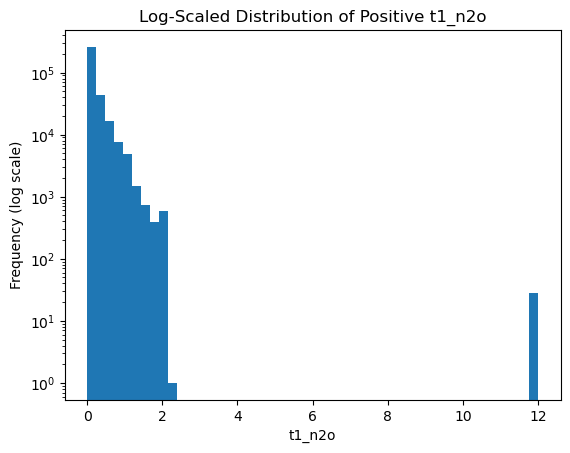

In [26]:
#Plot distribution of positive values for t1_n2o (log scale)

plt.figure()
plt.hist(numeric_features['t1_n2o'][numeric_features['t1_n2o'] > 0], bins=50)
plt.yscale("log")
plt.xlabel("t1_n2o")
plt.ylabel("Frequency (log scale)")
plt.title("Log-Scaled Distribution of Positive t1_n2o")
plt.show()

Note: for all features except for n2o, the percentage of negative values represent < 1% of the total observations. For n2o, the percentage of negative values is significantly higher at ~ 20.6%.  

In terms of the distribution of the negative values, for all concentration based variables, the negative values are distributed near zero. 

For inflow, the negative outliers are much larger in magnitude, with the minimum at -5572.5 m3. 

In [27]:
# Review distribution of negative inflow values 

#total number of negative inflow values
total_negative_inflow = (numeric_features['inflow'] < 0).sum()
print(f"Total number of negative inflow values: {total_negative_inflow}")

# Distribution of negative inflow values
negative_inflow_distribution = numeric_features[numeric_features['inflow'] < 0]['inflow'].describe()
print("Distribution of negative inflow values:")
print(negative_inflow_distribution)

Total number of negative inflow values: 198
Distribution of negative inflow values:
count     198.000000
mean     -833.994650
std      1002.812838
min     -5572.451660
25%     -1042.098358
50%      -358.183044
75%      -172.281803
max       -12.849655
Name: inflow, dtype: float64


In [28]:
# Check if negative values occur in isolated instances or in consecutive sequences

#Define mask for negative inflow values 
neg_mask = numeric_features["inflow"] < 0

# Identify consecutive sequences of negative inflow values
negative_sequences = neg_mask.groupby(neg_mask.ne(neg_mask.shift()).cumsum()).sum()

# Filter out instances of negative inflow 
negative_sequences = negative_sequences[negative_sequences > 0]

negative_sequences.describe()

count    189.000000
mean       1.047619
std        0.213524
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: inflow, dtype: float64

**Interpretation:** the count of isolated sequences of negative inflow values (1 or more consecutive negative values) is 189 which indicates that most of the negative observations are isolated instances (total number of negative inflow values is 198), likely caused by sensor issues, etc. 

The longest consecutive sequence of negative values is 2. Therefore we will use interpolation to estimate the missing inflow values using the length of the interval between the observations. 

##### Apply transformations to negative outliers

In [29]:
#Apply linear shift to negative concentration values 
cols_linear = ['t1_n2o','t1_nh4', 't1_no3', 't1_do']
min_values = df_t1[cols_linear].min() 
shifts = (-min_values).clip(lower=0)

#Apply constant shift to each column
df_t1[cols_linear] = df_t1[cols_linear].add(shifts)

In [30]:
#Verify minima 
df_t1[cols_linear].min()

t1_n2o    0.0
t1_nh4    0.0
t1_no3    0.0
t1_do     0.0
dtype: float64

In [31]:
#For inflow, interpolate values since negative outliers are isolated cases 

#Ensure that df is in chronological order
df_t1 = df_t1.sort_index()

#Identify negative inflow values and set to NaN
neg_mask_inflow = df_t1['inflow'] < 0 
df_t1.loc[neg_mask_inflow,'inflow'] = np.nan

#interpolate using length of interval between observations
df_t1['inflow'] = df_t1['inflow'].interpolate(method='time',limit_area='inside')

In [32]:

#Check for any remaining negative values 
remaining_negatives = (df_t1['inflow'] < 0).sum()
print(f"Number of remaining negative inflow values after interpolation: {remaining_negatives}")

#Check NaN values
nan_counts = df_t1['inflow'].isna().sum()
print(f"Number of NaN values in inflow after interpolation: {nan_counts}")

Number of remaining negative inflow values after interpolation: 0
Number of NaN values in inflow after interpolation: 112043


##### Check NaN values for Inflow 

In [33]:
#select inflow column and check for leading and trailing NaNs
inflow_s = df_t1["inflow"]
print("Leading NaNs:", inflow_s.isna().cumprod().sum())
print("Trailing NaNs:", inflow_s.isna()[::-1].cumprod().sum())

Leading NaNs: 112043
Trailing NaNs: 0


In [34]:
#Identify consecutive NaN gaps in inflow and compute their lengths
inflow_na = inflow_s.isna()
gap_id = inflow_na.ne(inflow_na.shift()).cumsum()
gap_lengths = inflow_na.groupby(gap_id).sum()
missing_gaps = gap_lengths[gap_lengths > 0]

missing_gaps.describe()


count         1.0
mean     112043.0
std           NaN
min      112043.0
25%      112043.0
50%      112043.0
75%      112043.0
max      112043.0
Name: inflow, dtype: float64

In [35]:
#Check when NaN values occur
first_valid = inflow_s.first_valid_index()

print("NaNs occur from", inflow_s.index.min(), "to", inflow_s.loc[:first_valid].index[inflow_s.loc[:first_valid].isna()].max())
print("Any NaNs after first valid?", inflow_s.loc[first_valid:].isna().any())


NaNs occur from 2022-06-11 22:01:00+00:00 to 2022-09-12 10:13:00+00:00
Any NaNs after first valid? False


**Interpretation:**

NaN values for inflow occur in one continuous missing block of 112,043 rows from 2022-06-11 22:01:00+00:00 to 2022-09-12 10:13:00+00:00 in the beginning of the dataset. 

To be handled in the next step when eliminating gaps in the dataset. 

#### Resample data (2 min intervals)

The data will initially be resampled to 2 minute intervals for EDA and segmentation, and later resampled to 10-minute intervals for modelling. 

The objective of the 2-min resampling is to regularize timestamps and provide a master dataset with the highest meaningful resolution. 

In [36]:
#Ensure datetime index is in chronological order
df_t1 = df_t1.sort_index()

#Re-sample to 2-minute intervals using mean aggregation
df_2T = df_t1.resample("2T").mean().copy() 

print("Shape before 2T resampling:", df_t1.shape)
print("Shape after 2T resampling:", df_2T.shape)

#Check sampling interval 
print(df_2T.index.to_series().diff().value_counts().head())

Shape before 2T resampling: (798466, 34)
Shape after 2T resampling: (526320, 34)
time
0 days 00:02:00    526319
Name: count, dtype: int64


In [ ]:
vars_to_check = ["t1_n2o", "t1_do", "t1_airflow",
                 "t1_nh4", "t1_no3", "t1_temp"]

valid = df_2T[vars_to_check].notna().all(axis=1)
invalid = ~valid

In [41]:
valid = df_2T[vars_to_check].notna().all(axis=1)
print("Fully valid rows (%):", round(valid.mean()*100, 2))

Fully valid rows (%): 83.05


### II. Exploratory Data Analysis 

#### Global EDA (raw data - before resampling)

##### Global Timeseries Overview 

In [42]:
#Check descriptive statistics after treating negative values 
df_t1[cols_num].describe().round(2) 

,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,686423.00,520534.00,470173.00,505759.00,520548.00,519651.00,510296.00,520583.00,505210.00,518090.00
mean,3100.25,17134.54,2188.87,0.13,2.31,3.12,0.65,2.55,15.66,1.12
std,2327.95,7339.69,2133.81,0.24,2.21,2.78,0.61,0.86,3.38,0.96
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.49,0.00
25%,2095.49,11566.58,0.00,0.01,0.95,1.52,0.19,2.14,12.62,0.51
50%,2310.76,16801.08,2166.19,0.04,1.87,2.51,0.37,2.55,15.64,0.89
75%,4322.92,21809.25,4020.05,0.14,3.03,4.07,1.03,2.96,18.91,1.44
max,17192.57,43356.56,12973.05,12.02,20.01,53.00,10.89,35.09,27.13,16.56


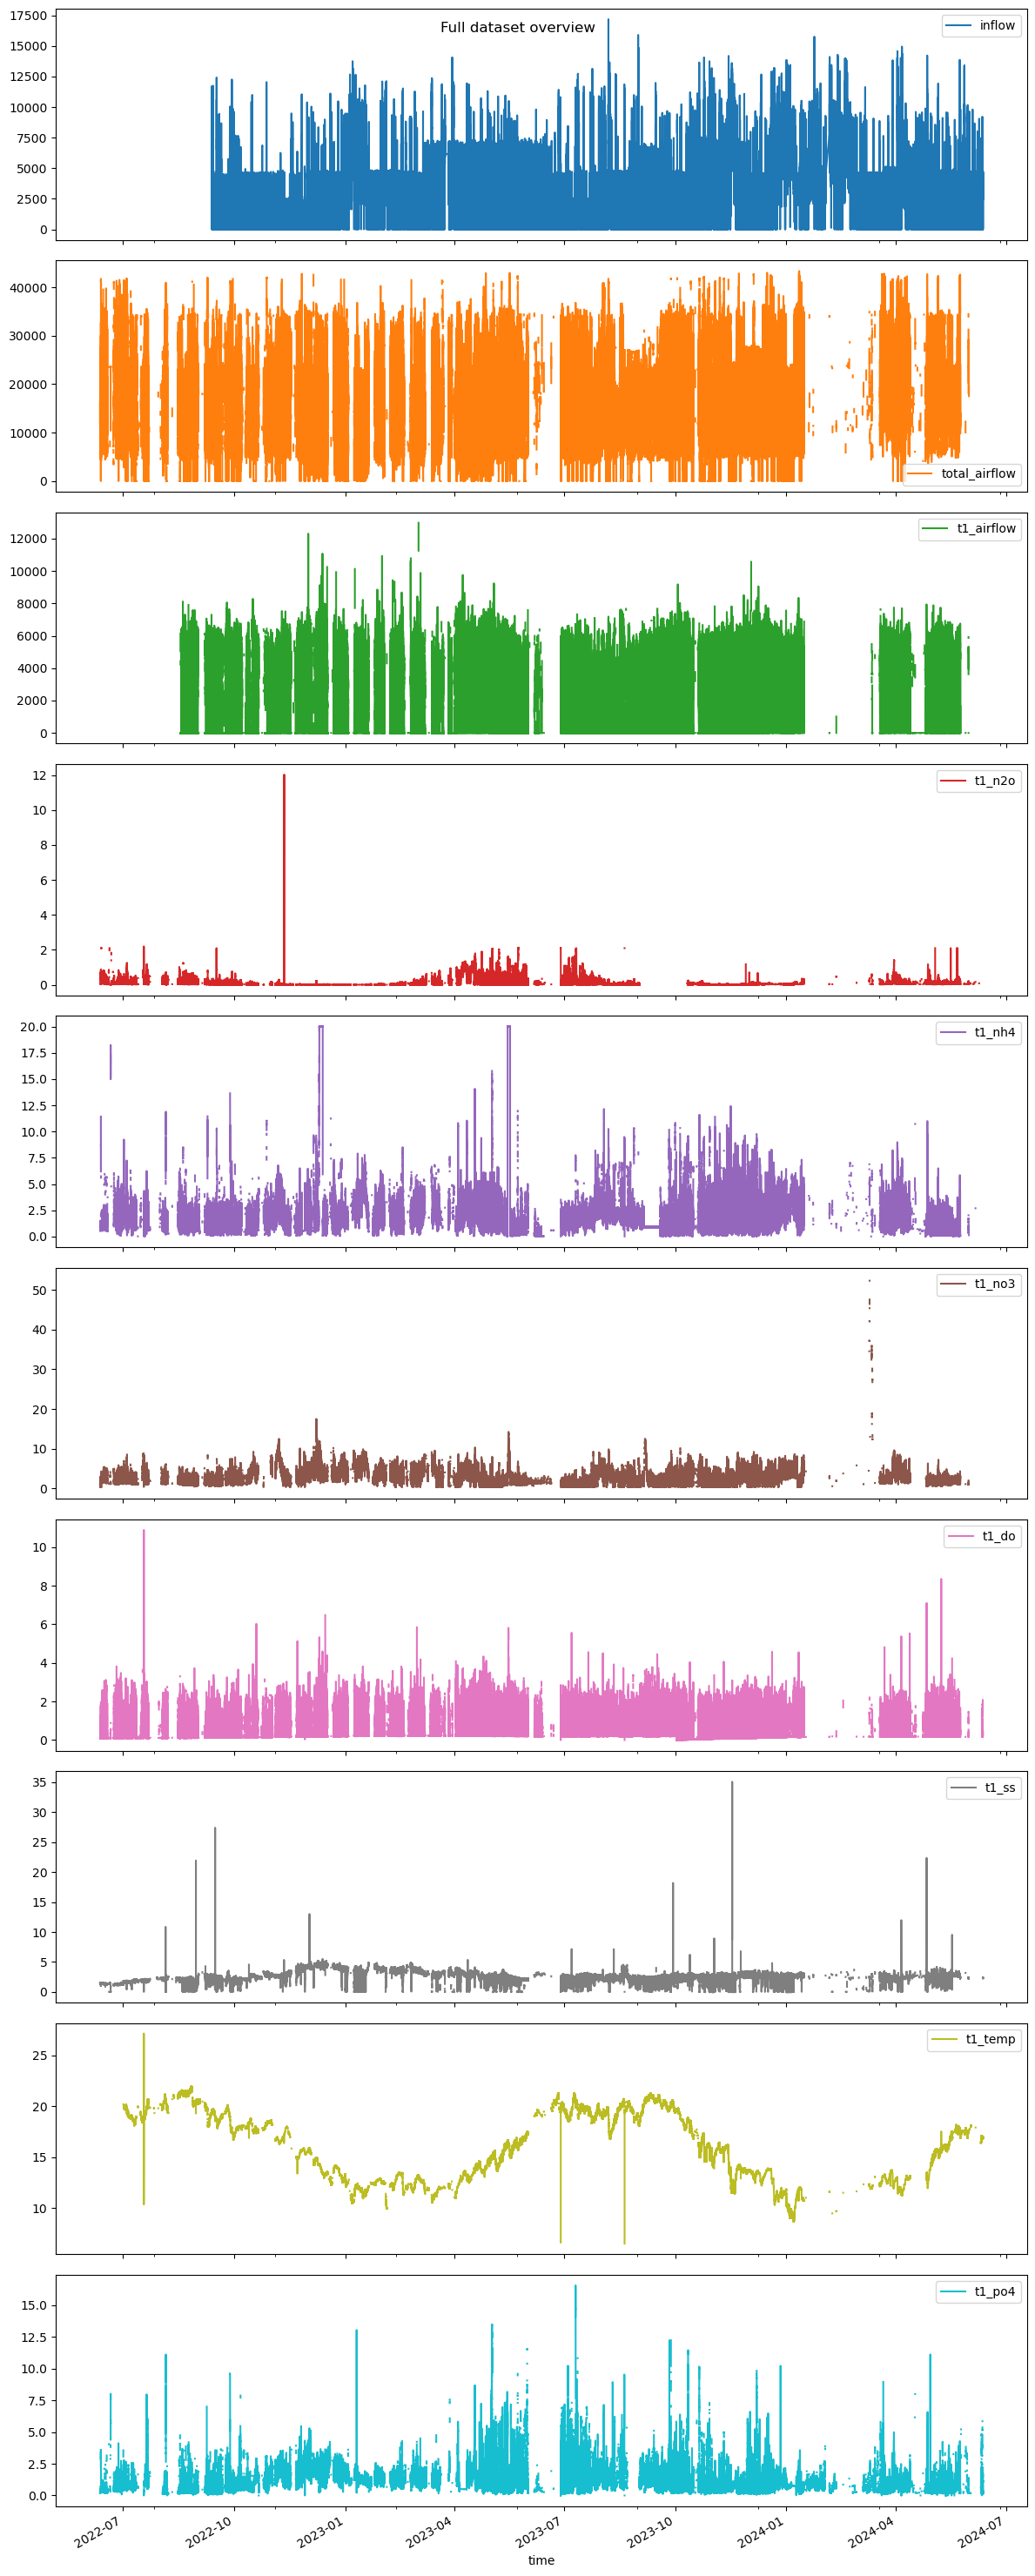

In [43]:
plot_df = df_t1[cols_num].copy() 
plot_df.plot(subplots=True, figsize=(12,30), title="Full dataset overview") 
plt.tight_layout()
plt.show() 

#### Local EDA 

##### Handling missing values

An initial threshold of 1 day is applied to df_2T to drop consecutive periods where data is missing for t1_n2o, t1_do, t1_airflow, t1_nh4, t1_no3, and t1_temp.

In [44]:
df_clean = df_2T.copy()

#ensure chronological order
df_clean = df_clean.sort_index()

#Check for missing values across each variable 
missing_values = df_clean.isnull().sum() 
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
total_airflow       7687
total_airflow_q     7687
t1_valve_pct       25955
t1_valve_pct_q     25955
t1_n2o             22156
t1_n2o_q           22156
t1_nh4              6958
t1_nh4_q            6958
t1_no3              7927
t1_no3_q            7927
t1_do              17881
t1_do_q            17881
t1_do_sp           90109
t1_do_sp_q         90109
t1_phase            9730
t1_phase_q          9730
t1_airflow         57886
t1_airflow_q       57886
t1_ss               6851
t1_ss_q             6851
t1_temp            22685
t1_temp_q          22685
phasecode          90109
phasecode_q        90109
inlet_tank         90109
inlet_tank_q       90109
outlet_tank        90109
outlet_tank_q      90109
t1_po4              9867
t1_po4_q            9867
inflow             72010
inflow_q           75277
storm_mode         90107
storm_mode_q       90107
dtype: int64


In [46]:
#Check sampling frequency
time_diffs = df_clean.index.to_series().diff()
print(time_diffs.value_counts().head(10)) 

time
0 days 00:02:00    526319
Name: count, dtype: int64


In [48]:
def compute_gap_summary(df, vars_to_check):
    """
    Compute consecutive missing blocks for selected variables.
    Returns gap_summary dataframe.
    """
    
    df = df.sort_index()
    
    # Identify rows where at least one selected variable is missing
    valid = df[vars_to_check].notna().all(axis=1)
    invalid = ~valid
    
    # Identify consecutive invalid blocks
    block_id = invalid.ne(invalid.shift()).cumsum()
    invalid_blocks = df.loc[invalid].groupby(block_id[invalid])
    
    # Summarise each block
    def summarize_gap(g):
        return pd.Series({
            "start_time": g.index.min(),
            "end_time": g.index.max(),
            "n_rows": len(g),
            "duration": g.index.max() - g.index.min()
        })
    
    gap_summary = invalid_blocks.apply(summarize_gap)
    
    if len(gap_summary) > 0:
        gap_summary = gap_summary.sort_values("duration", ascending=False)
    
    return gap_summary


In [49]:
gap_summary_raw = compute_gap_summary(df_t1, vars_to_check)
gap_summary_2T = compute_gap_summary(df_2T, vars_to_check)

In [50]:
print("---- RAW DATA (df_t1) ----")
print("Number of gaps:", len(gap_summary_raw))
print("Total missing duration:", gap_summary_raw["duration"].sum())
print("Mean gap duration:", gap_summary_raw["duration"].mean())

print("\n---- RESAMPLED DATA (df_2T) ----")
print("Number of gaps:", len(gap_summary_2T))
print("Total missing duration:", gap_summary_2T["duration"].sum())
print("Mean gap duration:", gap_summary_2T["duration"].mean())

---- RAW DATA (df_t1) ----
Number of gaps: 69524
Total missing duration: 354 days 20:40:00
Mean gap duration: 0 days 00:07:20.998791784

---- RESAMPLED DATA (df_2T) ----
Number of gaps: 16723
Total missing duration: 100 days 16:24:00
Mean gap duration: 0 days 00:08:40.184177480


In [51]:
print("Top 10 RAW gaps:")
print(gap_summary_raw.head(10))

print("\nTop 10 2T gaps:")
print(gap_summary_2T.head(10))

Top 10 RAW gaps:
                      start_time                  end_time  n_rows  \
1      2022-06-11 22:01:00+00:00 2022-08-17 11:26:00+00:00   82210   
117497 2023-09-01 08:42:00+00:00 2023-10-11 08:38:00+00:00   43812   
132249 2024-02-05 19:34:00+00:00 2024-03-11 19:16:00+00:00   50365   
132247 2024-01-15 19:22:00+00:00 2024-02-05 19:32:00+00:00   25722   
84477  2023-06-14 10:21:00+00:00 2023-06-28 08:35:00+00:00   20015   
134027 2024-04-12 17:33:00+00:00 2024-04-26 02:12:00+00:00   19079   
139009 2024-05-24 05:00:00+00:00 2024-05-30 17:15:00+00:00    9375   
139047 2024-06-05 16:31:00+00:00 2024-06-11 21:59:00+00:00    8969   
132257 2024-03-12 08:16:00+00:00 2024-03-18 10:43:00+00:00    8778   
139045 2024-05-30 22:20:00+00:00 2024-06-05 16:29:00+00:00    8288   

               duration  
1      66 days 13:25:00  
117497 39 days 23:56:00  
132249 34 days 23:42:00  
132247 21 days 00:10:00  
84477  13 days 22:14:00  
134027 13 days 08:39:00  
139009  6 days 12:15:00  
1390

**Note:** 
Largest gap in the data is 66 days across the selected variables, followed by 3 and 2 day gaps. Note that gap analysis on the raw data set significantly overestimates data missingnesss due to asynchronous sensor logging. 

In [54]:
#Drop gaps > 1 day in df_clean
big_gaps = gap_summary_2T[
    gap_summary_2T["duration"] > pd.Timedelta(days=1)
][["start_time", "end_time"]]

print("Number of gaps > 1 day:", len(big_gaps))

for start, end in zip(big_gaps["start_time"], big_gaps["end_time"]):
    df_clean = df_clean.drop(df_clean.loc[start:end].index)

print("Original shape:", df_2T.shape)
print("Shape after dropping >1 day gaps:", df_clean.shape)

Number of gaps > 1 day: 3
Original shape: (526320, 34)
Shape after dropping >1 day gaps: (474142, 34)


In [55]:
valid_after = df_clean[vars_to_check].notna().all(axis=1)
print("Rows fully valid after (%):",
      round(valid_after.mean() * 100, 2))

Rows fully valid after (%): 92.19


In [56]:
expected_interval = pd.Timedelta(minutes=2)

time_jump = df_clean.index.to_series().diff()

df_clean["segment_id"] = (
    time_jump > expected_interval
).cumsum().astype(int)

print("Number of segments:",
      df_clean["segment_id"].nunique())

Number of segments: 3


In [58]:
segment_summary = df_clean.groupby("segment_id").apply(
    lambda g: pd.Series({
        "start_time": g.index.min(),
        "end_time": g.index.max(),
        "duration": g.index.max() - g.index.min(),
        "n_rows": len(g)
    })
)

segment_summary = segment_summary.sort_values(
    "duration",
    ascending=False
)

print("Top 10 longest segments:")
print(segment_summary.head(10))

Top 10 longest segments:
                          start_time                  end_time  \
segment_id                                                       
1          2023-03-27 07:52:00+00:00 2024-02-02 15:12:00+00:00   
0          2022-08-17 11:02:00+00:00 2023-03-24 13:16:00+00:00   
2          2024-02-05 18:54:00+00:00 2024-06-11 21:58:00+00:00   

                    duration  n_rows  
segment_id                            
1          312 days 07:20:00  224861  
0          219 days 02:14:00  157748  
2          127 days 03:04:00   91533  


In [60]:
df_clean.reset_index().to_csv(
    "../../data/df_master.csv",
    index=False
)

### Additional notes on the data + next steps  

For feature engineering: 
- Add DO error (difference between DO actual and setpoint)?
 
Analysis: 
- Check feature wise for missing data gaps (how does the size of the gaps change when less features are used?)


Data source: https://data.mendeley.com/datasets/xmbxhscgpr/4